## Main analysis of the code and generation of results

In [19]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import numpy as np
import pandas as pd
from data_input import load_excess_returns_from_kenneth_french_path, prepare_returns
from pathlib import Path
from markowitz import markowitz_unconstrained
from sharpe_ratio import calculate_sharpe_ratio, rolling_sharpe_ratio, certainty_equivalent
from alternative_investment_rules import equal_weight_strategy, market_weight_strategy, historical_expectations_weights, rolling_window_weights, minimum_variance_strategy, jorion_bayes_stein_strategy, kan_zhou_three_fund_strategy

In [3]:
import bayesian_averaging

In [22]:
BASE_DIR = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()

DATA_PATH = BASE_DIR / "../../datasets/12_Industry_Portfolios_Daily.csv"
RISK_FREE_RATE_PATH = BASE_DIR / "../../datasets/F-F_Research_Data_Factors_daily.csv"

#next steps:
# need to build markowitz constrained.
# after we have the weight functions, we can look at teh oriingal returns files, calculate teh returns achieved by the portfolio
# we use this to calculate the sharpe ratio

In [13]:
df_excess_returns = load_excess_returns_from_kenneth_french_path(start_date="2015-07-01")
df_excess_returns_prepared = prepare_returns(df_excess_returns, drop_cols=("Date", "Other", "RF"))
df_risk_free_rate = df_excess_returns["RF"]
burn_in = 10
periods_until_investment = 990

In [18]:
certainty_bayesian = certainty_equivalent (df_excess_Returns_1963_prepared, original_replication_bayesian_weights, df_risk_free_from_1963)
certainty_bayesian

NameError: name 'df_excess_Returns_1963_prepared' is not defined

In [24]:
predicted_means_and_covs = bayesian_averaging.run_core(df_excess_returns_prepared, burn_in=burn_in)

Processing time step 100 / 2642...
Processing time step 200 / 2642...
Processing time step 300 / 2642...
Processing time step 400 / 2642...
Processing time step 500 / 2642...
Processing time step 600 / 2642...
Processing time step 700 / 2642...
Processing time step 800 / 2642...
Processing time step 900 / 2642...
Processing time step 1000 / 2642...
Processing time step 1100 / 2642...
Processing time step 1200 / 2642...
Processing time step 1300 / 2642...
Processing time step 1400 / 2642...
Processing time step 1500 / 2642...
Processing time step 1600 / 2642...
Processing time step 1700 / 2642...
Processing time step 1800 / 2642...
Processing time step 1900 / 2642...
Processing time step 2000 / 2642...
Processing time step 2100 / 2642...
Processing time step 2200 / 2642...
Processing time step 2300 / 2642...
Processing time step 2400 / 2642...
Processing time step 2500 / 2642...
Processing time step 2600 / 2642...


In [25]:
bayesian_weights = markowitz_unconstrained(predicted_means_and_covs, df_excess_returns_prepared, burn_in=burn_in, periods_until_investment=periods_until_investment)
bayesian_weights

,NoDur,Durbl,Manuf,Enrgy,Chems,BusEq,Telcm,Utils,Shops,Hlth,Money,Mkt-RF
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2637,-0.449433,-11.354741,20.952626,11.980046,17.190831,33.375068,30.925770,22.168924,19.541760,11.125728,21.444978,22.683796
2638,3.325068,-51.169428,24.300115,7.007719,20.026828,34.682997,27.160126,18.914700,19.700691,16.254931,24.306543,23.553091
2639,5.543000,-60.875741,14.114275,2.815661,16.801101,22.910810,22.528963,15.536741,18.186320,12.208887,11.794344,14.928370
2640,1.348728,-62.138243,2.138547,15.699435,10.822369,17.165757,33.395365,17.528609,10.441137,1.893137,5.396412,9.802635


In [26]:
sharpe_ratio_bayesian = calculate_sharpe_ratio(df_excess_returns_prepared, bayesian_weights)

sharpe_ratio_bayesian   

0.017154678915402993

In [27]:
sharpe_ratio_rolling_50 = rolling_sharpe_ratio(df_excess_returns_prepared, bayesian_weights, window=50)
sharpe_ratio_rolling_100 = rolling_sharpe_ratio(df_excess_returns_prepared, bayesian_weights, window=100)
rolling_check = sharpe_ratio_rolling_100.dropna().head()
rolling_check


1100    0.187748
1101    0.185585
1102    0.182955
1103    0.184848
1104    0.191489
dtype: float64

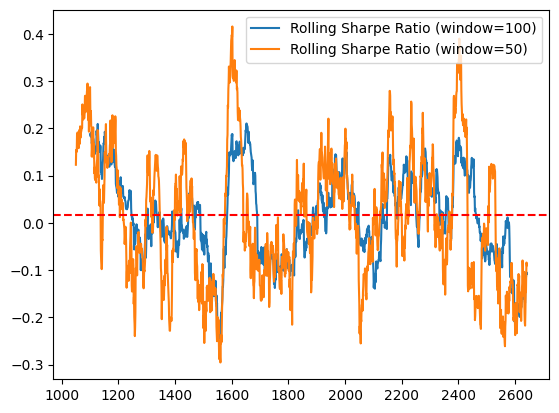

In [30]:
import matplotlib.pyplot as plt
plt.plot(sharpe_ratio_rolling_100, label="Rolling Sharpe Ratio (window=100)")
plt.plot(sharpe_ratio_rolling_50, label="Rolling Sharpe Ratio (window=50)")
plt.axhline(y=sharpe_ratio_bayesian, color = "red", linestyle="--")
plt.legend()
plt.show()

#how the hell does rolling sharpe exist here when we havent invested anything on day 1000?

In [4]:
df_excess_Returns_1963 = load_excess_returns_from_kenneth_french_path(start_date="1963-07-01", end_date="2011-12-31")
df_excess_Returns_1963_prepared = prepare_returns(df_excess_Returns_1963, drop_cols=("Date", "Other", "RF"))
df_risk_free_from_1963 = df_excess_Returns_1963["RF"]

In [5]:
one_over_n_weights = equal_weight_strategy(df_excess_Returns_1963_prepared, burn_in=1000)

sharpe_ratio_1_over_n = calculate_sharpe_ratio(df_excess_Returns_1963_prepared, one_over_n_weights)
sharpe_ratio_1_over_n


0.02414654981920102

In [6]:
market_weights = market_weight_strategy(df_excess_Returns_1963_prepared, burn_in=1000)
sharpe_ratio_market_weight = calculate_sharpe_ratio(df_excess_Returns_1963_prepared, market_weights)
sharpe_ratio_market_weight

0.01959237908630378

In [28]:
jorion_weights = jorion_bayes_stein_strategy ( df_excess_Returns_1963_prepared, burn_in=1000)
jorion_weights_rolling_sharpe = rolling_sharpe_ratio(df_excess_Returns_1963_prepared, jorion_weights, window= 100)

In [27]:
jorion_weights_rolling_sharpe

0.07449797760810788

In [7]:
one_over_rolling_sharpe = rolling_sharpe_ratio(df_excess_Returns_1963_prepared, one_over_n_weights, 50)
market_weight_rolling_sharpe = rolling_sharpe_ratio(df_excess_Returns_1963_prepared, market_weights, window = 50)


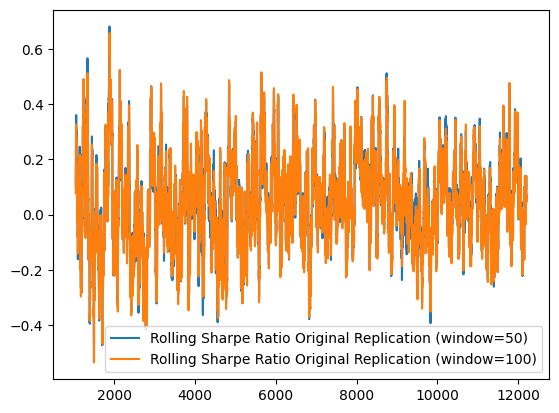

In [8]:
import matplotlib.pyplot as plt
plt.plot(one_over_rolling_sharpe, label="Rolling Sharpe Ratio Original Replication (window=50)")
plt.plot(market_weight_rolling_sharpe, label="Rolling Sharpe Ratio Original Replication (window=100)")
plt.legend()
plt.show()

In [11]:
import pickle
with open ("file.pkl", "rb") as f:
    original_replication_predicted_means_and_covs = pickle.load(f)

In [16]:
original_replication_bayesian_weights = markowitz_unconstrained(
    original_replication_predicted_means_and_covs,
    df_excess_Returns_1963_prepared,
    burn_in=burn_in,
    periods_until_investment=periods_until_investment
)
sharpe_ratio_original_replication = calculate_sharpe_ratio(df_excess_Returns_1963_prepared, original_replication_bayesian_weights)
sharpe_ratio_original_replication

0.19949883772109236

In [17]:
rolling_sharpe_ratio_original_replication_50 = rolling_sharpe_ratio(df_excess_Returns_1963_prepared, original_replication_bayesian_weights, window=50)
rolling_sharpe_ratio_original_replication_100 = rolling_sharpe_ratio(df_excess_Returns_1963_prepared, original_replication_bayesian_weights, window=100)
rolling_sharpe_ratio_original_replication_250 = rolling_sharpe_ratio(df_excess_Returns_1963_prepared, original_replication_bayesian_weights, window=250)

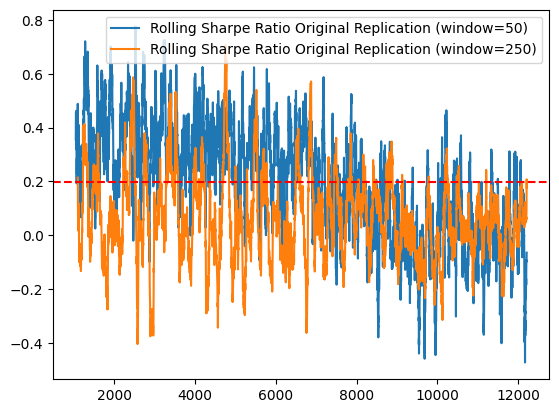

In [34]:
import matplotlib.pyplot as plt
plt.plot(rolling_sharpe_ratio_original_replication_50, label="Rolling Sharpe Ratio Original Replication (window=50)")
#plt.plot(rolling_sharpe_ratio_original_replication_100, label="Rolling Sharpe Ratio Original Replication (window=100)")
plt.plot(jorion_weights_rolling_sharpe, label="Rolling Sharpe Ratio Original Replication (window=250)")
#plt.plot(one_over_rolling_sharpe, label= " one over n ")
#plt.plot(market_weight_rolling_sharpe, label = "market strat")
plt.axhline(y=sharpe_ratio_original_replication, color = "red", linestyle="--")
plt.legend()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

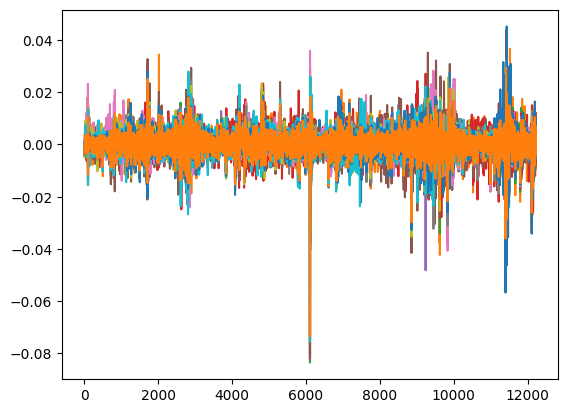

In [ ]:
plt.plot(pd.DataFrame(original_replication_predicted_means_and_covs["mu_hat"]))
plt.show
